<a href="https://colab.research.google.com/github/manavdhelia/ML-for-engineers/blob/HW4/hw4_1b_architecture_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECE 601 — HW4 Problem 1(b)
## Architecture Comparison: 1 vs 2 vs 3 Hidden Layers on MNIST
**UMass Amherst, Spring 2026** — builds directly on Part (a)

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

BATCH_SIZE = 64
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)
print(f'Train: {len(train_dataset):,}  |  Test: {len(test_dataset):,}')

Train: 60,000  |  Test: 10,000


In [12]:
class FlexibleNet(nn.Module):
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, num_hidden=1):
        super().__init__()
        layers = [nn.Flatten()]
        in_dim = input_size
        for _ in range(num_hidden):
            layers.append(nn.Linear(in_dim, hidden_size))
            layers.append(nn.ReLU())
            in_dim = hidden_size
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters())


for n in [1, 2, 3]:
    m = FlexibleNet(num_hidden=n)
    print(f'{n} hidden layer(s): {count_params(m):,} parameters')
    print(m)
    print()

1 hidden layer(s): 203,530 parameters
FlexibleNet(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)

2 hidden layer(s): 269,322 parameters
FlexibleNet(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)

3 hidden layer(s): 335,114 parameters
FlexibleNet(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=256, bias=True)
    (6): ReLU()
    (7): Linear(in_features=256, out_features=10, bias

In [13]:
NUM_EPOCHS    = 10
LEARNING_RATE = 1e-3

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += out.max(1)[1].eq(labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, 100. * correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            out  = model(images)
            loss = criterion(out, labels)
            total_loss += loss.item() * images.size(0)
            correct    += out.max(1)[1].eq(labels).sum().item()
            total      += labels.size(0)
    return total_loss / total, 100. * correct / total

print('Helpers defined.')

Helpers defined.


In [14]:
configs = {
    '1 hidden layer  (256)':         1,
    '2 hidden layers (256-256)':     2,
    '3 hidden layers (256-256-256)': 3,
}

history = {}

for label, num_hidden in configs.items():
    print(f'\n{"="*60}')
    print(f'Training: {label}')
    print(f'{"="*60}')

    model     = FlexibleNet(num_hidden=num_hidden).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    h = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>8}')
    print('-'*55)

    for epoch in range(1, NUM_EPOCHS + 1):
        tl, ta = train_epoch(model, train_loader, criterion, optimizer)
        vl, va = evaluate(model,   test_loader,  criterion)
        h['train_loss'].append(tl); h['train_acc'].append(ta)
        h['val_loss'].append(vl);   h['val_acc'].append(va)
        print(f'{epoch:>6} | {tl:>10.4f} | {ta:>8.2f}% | {vl:>8.4f} | {va:>7.2f}%')

    print('-'*55)
    print(f'Best test accuracy : {max(h["val_acc"]):.2f}%')
    history[label] = h



Training: 1 hidden layer  (256)
 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc
-------------------------------------------------------
     1 |     0.2260 |    93.33% |   0.1183 |   96.43%
     2 |     0.0934 |    97.21% |   0.0865 |   97.29%
     3 |     0.0642 |    97.97% |   0.0831 |   97.50%
     4 |     0.0463 |    98.52% |   0.0768 |   97.59%
     5 |     0.0357 |    98.85% |   0.0831 |   97.63%
     6 |     0.0307 |    98.98% |   0.0829 |   97.59%
     7 |     0.0237 |    99.23% |   0.0893 |   97.75%
     8 |     0.0204 |    99.32% |   0.0853 |   97.67%
     9 |     0.0189 |    99.35% |   0.0894 |   97.64%
    10 |     0.0175 |    99.40% |   0.0973 |   97.69%
-------------------------------------------------------
Best test accuracy : 97.75%

Training: 2 hidden layers (256-256)
 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc
-------------------------------------------------------
     1 |     0.2210 |    93.16% |   0.1108 |   96.28%
     2 |     0.0921 |    97.12% 

In [15]:
print(f'\n{"Architecture":<35} | {"Params":>8} | {"Best Val":>9} | {"Final Val":>9} | {"Final Train":>11}')
print('-'*82)

for label, num_hidden in configs.items():
    m      = FlexibleNet(num_hidden=num_hidden)
    params = count_params(m)
    h      = history[label]
    print(f'{label:<35} | {params:>8,} | {max(h["val_acc"]):>8.2f}% | {h["val_acc"][-1]:>8.2f}% | {h["train_acc"][-1]:>10.2f}%')


Architecture                        |   Params |  Best Val | Final Val | Final Train
----------------------------------------------------------------------------------
1 hidden layer  (256)               |  203,530 |    97.75% |    97.69% |      99.40%
2 hidden layers (256-256)           |  269,322 |    97.98% |    97.89% |      99.33%
3 hidden layers (256-256-256)       |  335,114 |    98.11% |    97.78% |      99.27%


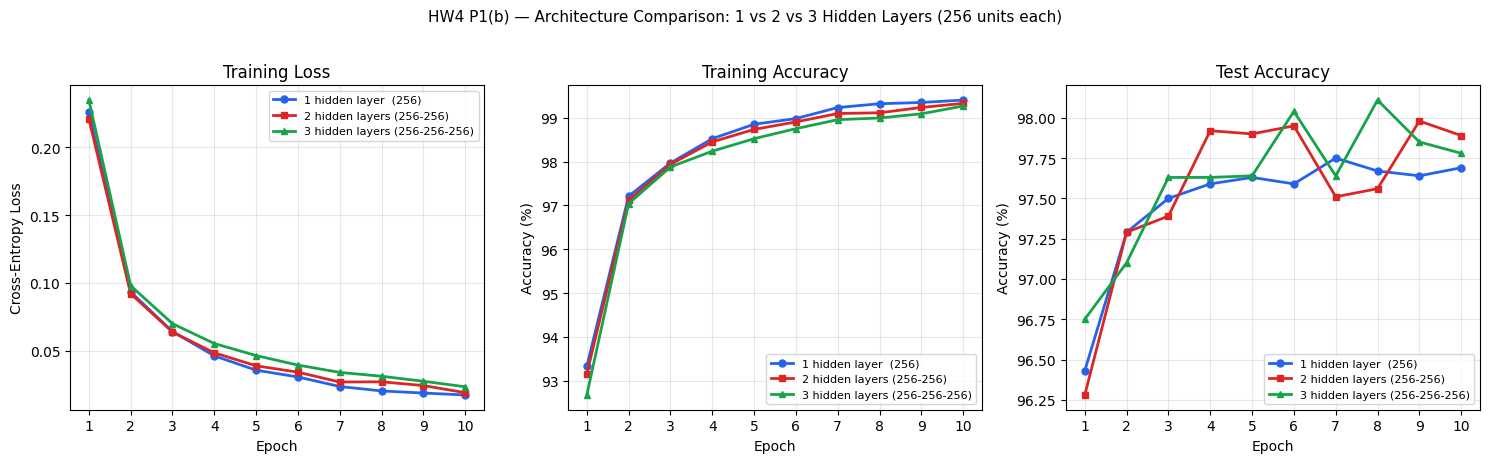

Figure saved as hw4_p1b_comparison.png


In [16]:
colors   = ['#2563eb', '#dc2626', '#16a34a']
markers  = ['o', 's', '^']
epochs   = range(1, NUM_EPOCHS + 1)
labels   = list(configs.keys())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1: Training Loss
for i, lbl in enumerate(labels):
    axes[0].plot(epochs, history[lbl]['train_loss'],
                 color=colors[i], marker=markers[i], linewidth=2, markersize=5, label=lbl)
axes[0].set_title('Training Loss');  axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss'); axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3); axes[0].set_xticks(list(epochs))

# 2: Training Accuracy
for i, lbl in enumerate(labels):
    axes[1].plot(epochs, history[lbl]['train_acc'],
                 color=colors[i], marker=markers[i], linewidth=2, markersize=5, label=lbl)
axes[1].set_title('Training Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3); axes[1].set_xticks(list(epochs))

# 3: Test (Validation) Accuracy
for i, lbl in enumerate(labels):
    axes[2].plot(epochs, history[lbl]['val_acc'],
                 color=colors[i], marker=markers[i], linewidth=2, markersize=5, label=lbl)
axes[2].set_title('Test Accuracy');  axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy (%)'); axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3); axes[2].set_xticks(list(epochs))

plt.suptitle('Architecture Comparison: 1 vs 2 vs 3 Hidden Layers (256 units each)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('hw4_p1b_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as hw4_p1b_comparison.png')